1. Import library yang dibutuhin 

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import pandas as pd
import numpy as np

from collections import Counter

from IPython.display import display

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

2. Ambil data

In [26]:
file_path = 'spam.csv'

try:
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        print("UTF-8 decoding failed, trying 'latin1'...")
        df = pd.read_csv(file_path, encoding='latin1')

    print("Dataset loaded successfully!")
    print("\nDataset Information:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

UTF-8 decoding failed, trying 'latin1'...
Dataset loaded successfully!

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


3. Proses bersihin datanya ( ini harusnya di run pertama)

In [27]:
df_cleaned = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
df_cleaned = df_cleaned.rename(columns={'v1': 'label', 'v2': 'message'})

# NAMBAHIN kolom panjang pesan
df_cleaned['message_length'] = df_cleaned['message'].apply(len)

#Ubah label teks menjadi numerik (0 = ham, 1 = spam)
df_cleaned['label'] = df_cleaned['label'].map({'ham': 0, 'spam': 1})

#Hapus baris yang kosong setelah mapping biar lebih aman ?
df_cleaned = df_cleaned.dropna(subset=['label'])

#inisialisasi NLTK tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower() #ngubah teks menjadi huruf kecil semua
    text = re.sub(r'[^a-z\s]', ' ', text) #hapus tanda baca dan angka tapi ga nyatuin kata
    words = text.split() #Tokenisasi sederhana dengan base spasi
    #lemmatization dan stopword removal
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

#pembersihan dan buat kolom baru
df_cleaned['clean_message'] = df_cleaned['message'].apply(clean_text)

print("\nDataset setelah dibersihkan dan diproses:")
display(df_cleaned[['label', 'message', 'clean_message']].head())


Dataset setelah dibersihkan dan diproses:


,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


3 Bagian II : Buktiin data bukan sintetik atau kebocoran data (Dataset UCI Mechine Learning)

Analisa Sintetik atau Natural Menggunakan Hukum Zipf?

Hasil Analisis Zipf:
-> Nilai Alpha (α)   : 1.1293
-> Kedekatan Garis (R²): 0.9631

NATURAL


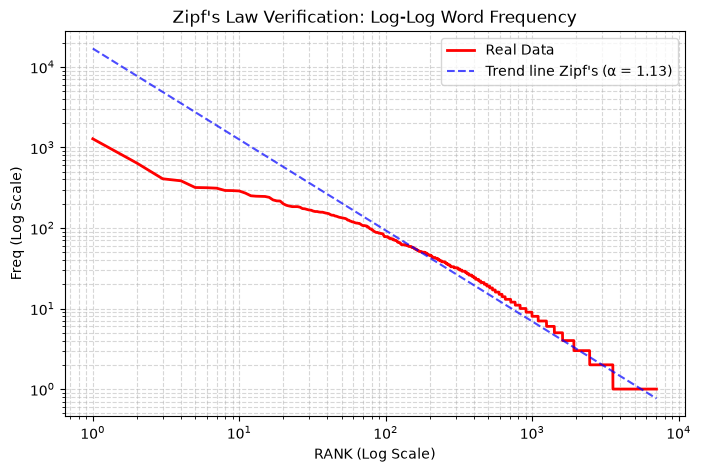

In [28]:
print("Analisa Sintetik atau Natural Menggunakan Hukum Zipf?\n")

# ==========================================
# Zipf's Law Analysis & Regresi Linier
# ==========================================
# 1. Hitung frekuensi setiap kata
all_words = ' '.join(df_cleaned['clean_message']).split()
word_counts = Counter(all_words)
frequencies = np.array(sorted(word_counts.values(), reverse=True))

# 2. Buat peringkat (ranks)
ranks = np.arange(1, len(frequencies) + 1)

# 3. Transformasikan ke skala Logaritma
log_ranks = np.log10(ranks)
log_freqs = np.log10(frequencies)

# 4. Cari nilai alpha (-slope) menggunakan Regresi Linier (Polinomial derajat 1)
# rumus asli: log(f) = log(C) - alpha * log(r)
slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
alpha = -slope  # Nilai alpha adalah nilai positif dari kemiringan negatif

# 5. Hitung nilai R-squared (R2) untuk melihat seberapa "lurus" datanya
fitted_values = slope * log_ranks + intercept
residuals = log_freqs - fitted_values
ss_res = np.sum(residuals**2)
ss_tot = np.sum((log_freqs - np.mean(log_freqs))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Hasil Analisis Zipf:")
print(f"-> Nilai Alpha (α)   : {alpha:.4f}")
print(f"-> Kedekatan Garis (R²): {r_squared:.4f}\n")

# ==========================================
# Penentuan Sintetik vs Natural Berbasis Zipf
# ==========================================
# Data alami biasanya punya 0.8 <= alpha <= 1.2 dan garis yang sangat lurus (R² > 0.90)
if (0.75 <= alpha <= 1.35) and (r_squared >= 0.90):
    print("NATURAL")
else:
    print("SINTETIK")
    if r_squared < 0.90:
        print("Distribution Freq word not make a consistent line.")
    if alpha < 0.75 or alpha > 1.35:
        print(f"Freq low/lost to fast, inconsist (alpha: {alpha:.2f}).")


# ==========================================
# Visualisasi dengan Garis Tren Zipf
# ==========================================
plt.figure(figsize=(8, 5))
# Plot data asli Anda (Merah)
plt.plot(ranks, frequencies, color='red', linewidth=2, label="Real Data") 

# Plot garis tren ideal hasil rumus (Biru Putus-putus)
ideal_frequencies = 10**fitted_values
plt.plot(ranks, ideal_frequencies, color='blue', linestyle='--', alpha=0.7, 
         label=f"Trend line Zipf's (α = {alpha:.2f})")

plt.yscale('log')
plt.xscale('log')
plt.title("Zipf's Law Verification: Log-Log Word Frequency")
plt.xlabel("RANK (Log Scale)")
plt.ylabel("Freq (Log Scale)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

4. EDA ( Exploratory Data analysis)

In [29]:
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

print("\nMissing Values:")
display(df.isnull().sum())

print("\nUnique values in 'v1' column (if applicable):")
if 'v1' in df.columns:
    print(df['v1'].value_counts())
else:
    print("'v1' column not found.")

print("\nUnique values in 'v2' column (if applicable):")
if 'v2' in df.columns:
    print(df['v2'].head())
else:
    print("'v2' column not found.")


Descriptive Statistics:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2



Missing Values:


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


Unique values in 'v1' column (if applicable):
v1
ham     4825
spam     747
Name: count, dtype: int64

Unique values in 'v2' column (if applicable):
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: v2, dtype: str


5.  Vectorisasi..? dari teks ke angka

In [30]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.9)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_cleaned['clean_message'])

print("Bentuk matriks TF-IDF:", tfidf_matrix.shape)
print("Contoh fitur (kata-kata) yang digunakan:", tfidf_vectorizer.get_feature_names_out()[:20])

Bentuk matriks TF-IDF: (5572, 3448)
Contoh fitur (kata-kata) yang digunakan: ['aah' 'aathi' 'abi' 'ability' 'abiola' 'abj' 'able' 'absolutly' 'abt'
 'abta' 'aburo' 'ac' 'acc' 'accept' 'access' 'accident' 'accidentally'
 'accordingly' 'account' 'ache']


6. Train-Test Split (Membagi Data Latih dan Uji)

In [31]:
#Pisahin X dan Y
X = tfidf_matrix
y = df_cleaned['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16, stratify=y) #test_size for splitting data train and data tes.

print("Total Data Trainer (Training):", X_train.shape[0])
print("Total Data Tester (Testing):", X_test.shape[0])


Total Data Trainer (Training): 4457
Total Data Tester (Testing): 1115


7. Model 1: Linear SVM (Support Vector Machine)

--- Linear SVM ---
Akurasi: 0.9820627802690582

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



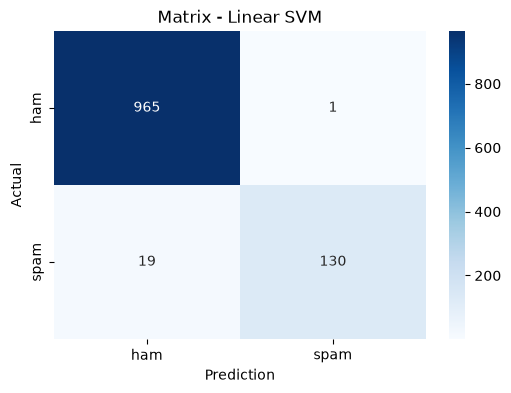

In [32]:
svm_model = LinearSVC(random_state=16)
svm_model.fit(X_train, y_train)

#prediksi data uji
svm_predictions = svm_model.predict(X_test)

#Evaluasi
print("--- Linear SVM ---")
print("Akurasi:", accuracy_score(y_test, svm_predictions))
print("\nClassification Report:\n", classification_report(y_test, svm_predictions, target_names=['ham', 'spam']))

#Visualisasi Confusion METRIK
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, svm_predictions), annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Matrix - Linear SVM')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()


8. Model 2: naive bayes

--- Multinomial Naive Bayes ---
Akurasi: 0.9739910313901345

Classification Report:
               precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       0.98      0.82      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



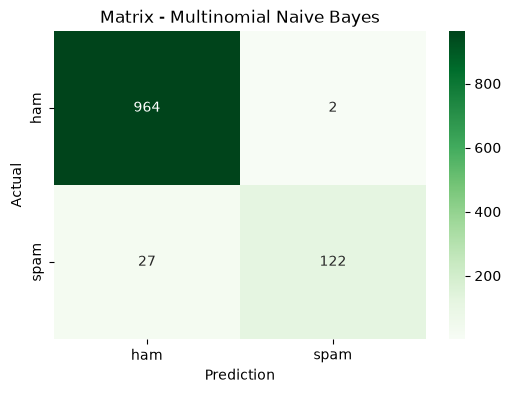

In [33]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

#Melakukan prediksi pada data uji
nb_predictions = nb_model.predict(X_test)

#Evaluasi
print("--- Multinomial Naive Bayes ---")
print("Akurasi:", accuracy_score(y_test, nb_predictions))
print("\nClassification Report:\n", classification_report(y_test, nb_predictions, target_names=['ham', 'spam']))

#visualin matrik
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, nb_predictions), annot=True, fmt='d', cmap='Greens',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Matrix - Multinomial Naive Bayes')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()


8. Model 3 : Random Forest testing

--- Random Forest ---
Akurasi: 0.9757847533632287

Classification Report:
               precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.82      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



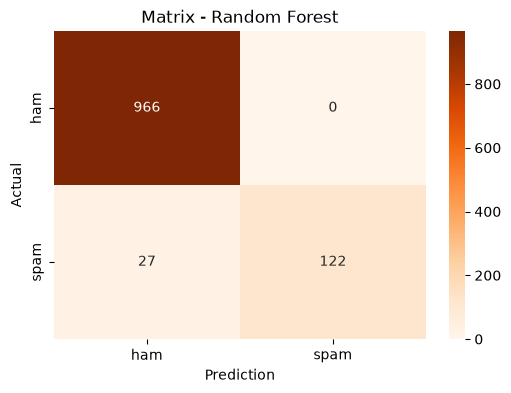

In [34]:

# Inisialisasi dan latih model Random Forest
# n_estimators=100 artinya kita pake 100 tree
rf_model = RandomForestClassifier(n_estimators=100, random_state=16)
rf_model.fit(X_train, y_train)

# Prediksi data yang uji
rf_predictions = rf_model.predict(X_test)

# Evaluasi
print("--- Random Forest ---")
print("Akurasi:", accuracy_score(y_test, rf_predictions))
print("\nClassification Report:\n", classification_report(y_test, rf_predictions, target_names=['ham', 'spam']))

# Visualisasi Metrikn nya
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Matrix - Random Forest')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

# Gabungan code 10 11


--- K-FOLD & Visualization ---
[Linear SVM]
AVG Accuracy  : 0.9838
AVG Precision : 0.9868
AVG Recall    : 0.8912
AVG F1-Score  : 0.9364
----------------------------------------
[Multinomial NB]
AVG Accuracy  : 0.9758
AVG Precision : 0.9921
AVG Recall    : 0.8259
AVG F1-Score  : 0.9002
----------------------------------------
[Random Forest]
AVG Accuracy  : 0.9803
AVG Precision : 0.9886
AVG Recall    : 0.8628
AVG F1-Score  : 0.9211
----------------------------------------


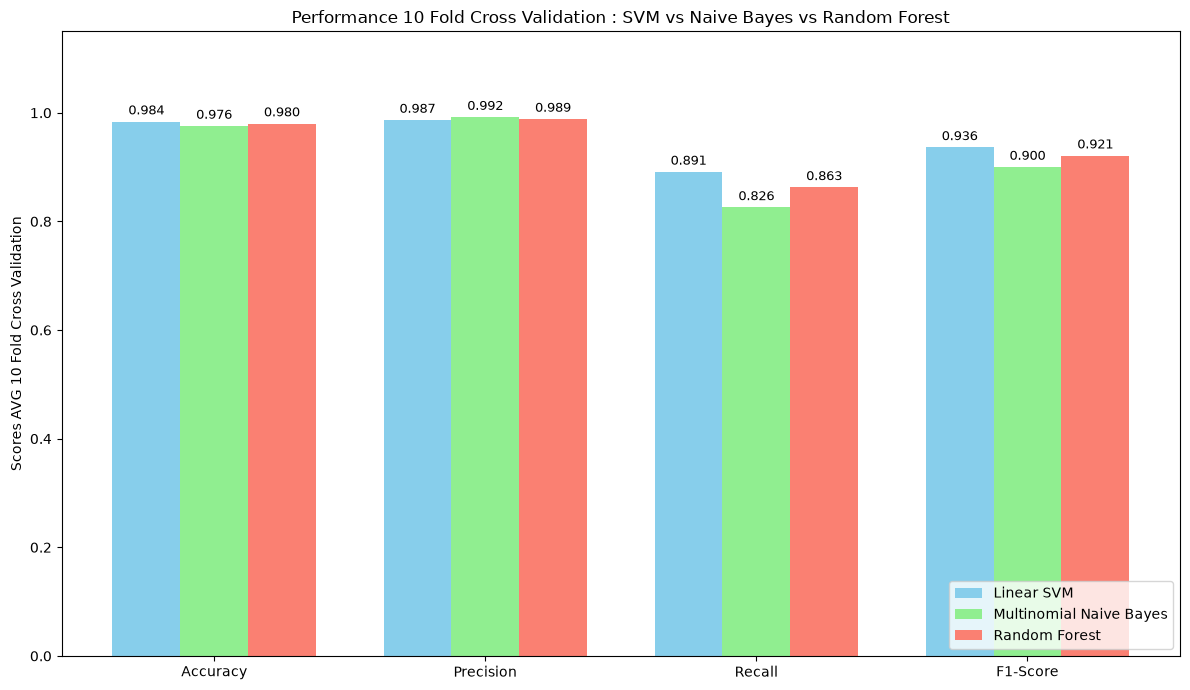

In [ ]:
print("\n" + "="*50)
print("--- K-FOLD & Visualization ---")
print("="*50)

#Random state sebagai penentu ternyata disini.
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Linear SVM": LinearSVC(random_state=42),
    "Multinomial NB": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42) #pake 100 pohon
}

#bikin dictionary kosong buat nampung hasil rata-rata CV tiap model
cv_results = {}

#looping pengujian & simpan nilai rata-ratanya
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy').mean()
    prec = cross_val_score(model, X_train, y_train, cv=skf, scoring='precision').mean()
    rec = cross_val_score(model, X_train, y_train, cv=skf, scoring='recall').mean() # Tambah recall buat chart
    f1 = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1').mean()
    
    #simpan ke dictionary dalam bentuk list [Accuracy, Precision, Recall, F1]
    cv_results[name] = [acc, prec, rec, f1]
    
    print(f"[{name}]")
    print(f"AVG Accuracy  : {acc:.4f}")
    print(f"AVG Precision : {prec:.4f}")
    print(f"AVG Recall    : {rec:.4f}")
    print(f"AVG F1-Score  : {f1:.4f}")
    print("-" * 40)

#chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

#ambil data yg udah dihitung dari atas
svm_scores = cv_results["Linear SVM"]
nb_scores = cv_results["Multinomial NB"]
rf_scores = cv_results["Random Forest"]

x = np.arange(len(metrics))
width = 0.25 

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width, svm_scores, width, label='Linear SVM', color='skyblue')
rects2 = ax.bar(x, nb_scores, width, label='Multinomial Naive Bayes', color='lightgreen')
rects3 = ax.bar(x + width, rf_scores, width, label='Random Forest', color='salmon')

# Label dan Judul
ax.set_ylabel('Scores AVG 10 Fold Cross Validation')
ax.set_title('Performance 10 Fold Cross Validation : SVM vs Naive Bayes vs Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')

# Angka di atas bar
ax.bar_label(rects1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(rects2, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(rects3, fmt='%.3f', padding=3, fontsize=9)

fig.tight_layout()
plt.show()